In [4]:
%load_ext autoreload
%autoreload 2
!module load latex

/mnt/sw/nix/store/7kfpfhj104s5hynnhr5jzsrm25p4vwla-python-3.11.11-view/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [5]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import argparse
import numpy as np
import os
import sys

sys.path.append("../src")
from experiment_config import (
    ExperimentConfig,
    HypercubeConfig,
    HilbertConfig,
    SamplerConfig,
    J1J2Config,
    ViT2DConfig,
    ConstantSchedule,
    CosineDecaySchedule,
    OptimizerConfig,
    SRConfig,
)
from new_logger import CheckpointCallback
import netket as nk
import matplotlib

/mnt/home/rwiersema/nqs_blurred_sampling/.venv/lib/python3.11/site-packages/matplotlib/axes/_axes.py:7003: ComplexWarning: Casting complex values to real discards the imaginary part
  tops = np.array(tops, float)  # causes problems later if it's an int


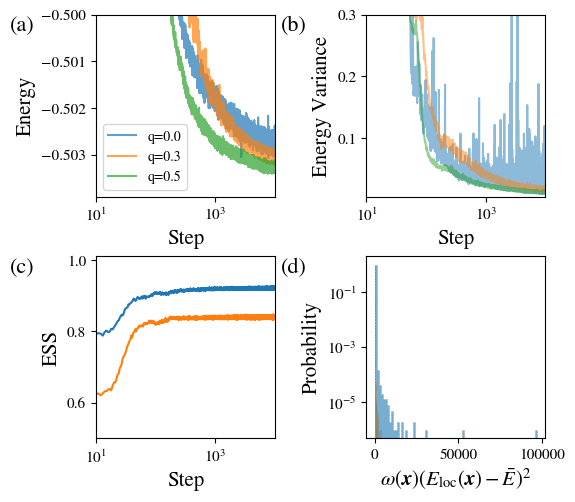

: 

In [ ]:
# Create figure with 2x2 subplots
matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"

fig = plt.figure(figsize=(5.8, 5.5))
gs = GridSpec(2, 2, figure=fig, width_ratios=[1, 1], wspace=0.51, hspace=0.33)
axs = np.array(
    [
        [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
        [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])],
    ]
)
CSs = {
    2: {2**14: 2**13},
    4: {2**14: 4096},
}
num_layers = 2
x_min = 10
ylim_vscore = {2: (2e-2, 5e-2), 4: (1e-2, 5e-2)}
ylim_mean = {2: (-0.5039, -0.50), 4: (-0.5039, -0.50)}
ylim_var = {2: (5e-3, 3e-1), 4: (5e-3, 3e-1)}
L = 6
ns = 2**14

for i, q in enumerate([0.0, 0.3, 0.5]):

    # Configuration dictionary
    config = {
        "ns": ns,
        "patch_size": 3,
        "num_layers": num_layers,
        "d_model": 72,
        "heads": 12,
        "L": L,
        "seed": 100,
        "experiment_name": "June18",
        "diag_shift": 1e-3,
        "lr": 0.01,
        "thermalizing_steps": 0,
        "chunk_size": CSs[num_layers][ns],
        "auto_tune_lr": False,
        "q_blur": q,
    }

    # Convert to namespace for compatibility with get_data
    args = argparse.Namespace(**config)
    lattice_cfg = HypercubeConfig(L=args.L, max_neighbor_order=2)
    hilbert_cfg = HilbertConfig(total_sz=0)
    system_cfg = J1J2Config(sign_rule=None)
    sampler_cfg = SamplerConfig(q_blur=args.q_blur)
    model_cfg = ViT2DConfig(
        patch_size=args.patch_size,
        num_layers=args.num_layers,
        d_model=args.d_model,
        heads=args.heads,
    )

    diag_shift_cfg = ConstantSchedule(args.diag_shift)
    lr_init = args.lr
    lr_cfg = CosineDecaySchedule(lr_init, 10000, lr_init / 10)
    variance_scaled = getattr(args, "variance_scaled", False)
    optimizer_cfg = OptimizerConfig(
        lr=lr_cfg, diag_shift=diag_shift_cfg, variance_scaled=variance_scaled
    )
    chunk_size = getattr(args, "chunk_size", None)
    momentum = getattr(args, "momentum", False)

    sr_cfg = SRConfig(chunk_size=chunk_size, momentum=momentum)

    config = ExperimentConfig(
        seed=args.seed,
        n_samples=args.ns,
        n_steps=10000,
        thermalize_steps=args.thermalizing_steps,
        root="./data",
        name=args.experiment_name,
        lattice=lattice_cfg,
        hilbert=hilbert_cfg,
        hamiltonian=system_cfg,
        sampler=sampler_cfg,
        model=model_cfg,
        optimizer=optimizer_cfg,
        sr=sr_cfg,
    )
    save_path = config.save_path()

    ckpt = CheckpointCallback(
        save_path, logger=nk.logging.RuntimeLog(), every_n_steps=25, wandb_run=False
    )
    logger, restored = ckpt.restore_logger()
    E = np.load(save_path + f"blurred_local_energies_q{q:1.1f}.npy").flatten()
    w = np.load(save_path + f"blurred_importance_weights_q{q:1.1f}.npy").flatten()
    # Extract energy data
    N = L**2
    energies_mean = np.array(logger.data["Energy"]["Mean"]).real / (4 * N)
    energies_variance = np.array(logger.data["Energy"]["Variance"]).real / (4 * N)
    energies_w_variance = np.array(logger.data["weighted_variance"]).real / (4 * N)
    try:
        ess_values = np.array(logger.data["ess"])
    except KeyError:
        ess_values = np.array([np.nan])

    try:
        accept_values = np.array(logger.data["acceptance"])
    except KeyError:
        accept_values = np.array([np.nan])

    # Mean energy (top left, zoomed convergence)
    ax = axs[0, 0]
    ax.plot(energies_mean, label=f"q={q}", alpha=0.7)
    ax.set_xlabel("Step", fontsize=15)
    ax.set_ylim(ylim_mean[num_layers])
    ax.set_xlim(x_min, 10000)
    ax.set_xscale("log")
    ax.set_ylabel("Energy", fontsize=15)
    # ax.grid(True)
    ax.legend()

    # Energy Variance (top right)
    axs[0, 1].plot(
        energies_w_variance,
        alpha=0.5,
    )
    axs[0, 1].set_xlabel("Step", fontsize=15)
    axs[0, 1].set_xscale("log")
    # axs[0, 1].set_yscale("log")
    axs[0, 1].set_ylabel("Energy Variance", fontsize=15)

    axs[0, 1].set_ylim(ylim_var[num_layers])
    axs[0, 1].set_xlim(x_min, 10000)
    # Variance
    ax_hist = axs[1, 1]
    w = w / np.mean(w)
    MeanE = np.mean(w * E).real
    Z = w * np.abs(E - MeanE) ** 2
    ax_hist.hist(
        Z,
        label=f"q={q}",
        bins=80,
        weights=np.ones_like(E) / w.size,
        alpha=0.6,
        histtype="stepfilled",
        linestyle="--",
        linewidth=0.4,
        edgecolor="grey",
    )
    ax_hist.set_yscale("log")
    ax_hist.set_xlabel(
        r"$\omega(\boldsymbol{x}) (E_{\mathrm{loc}}(\boldsymbol{x}) - \bar E)^2$",
        fontsize=15,
    )
    ax_hist.set_ylabel("Probability", fontsize=15)
    # Effective Sample Size (bottom left)
    if q == 0:
        continue
    axs[1, 0].plot(ess_values, label=f"q={q}")
    axs[1, 0].set_xlabel("Step", fontsize=15)
    axs[1, 0].set_xscale("log")
    axs[1, 0].set_ylabel(r"ESS", fontsize=15)
    axs[1, 0].set_ylim([0.5, 1.01])
    axs[1, 0].set_xlim(x_min, 10000)
    # axs[1, 0].grid(True)
for ax in axs.flatten():
    ax.tick_params(labelsize=11)

loc_x = -0.48
loc_y = 0.91
fs = 16
axs[0, 0].annotate("(a)", xy=(loc_x, loc_y), xycoords="axes fraction", fontsize=fs)
axs[0, 1].annotate("(b)", xy=(loc_x, loc_y), xycoords="axes fraction", fontsize=fs)
# loc_x = -0.28
# loc_y = 0.91
axs[1, 0].annotate("(c)", xy=(loc_x, loc_y), xycoords="axes fraction", fontsize=fs)
axs[1, 1].annotate("(d)", xy=(loc_x, loc_y), xycoords="axes fraction", fontsize=fs)

# Unused panel (bottom right)
# fig.suptitle(f"Ns = {ns}")
save_path = config.save_path()
fig_path = "./figures/" + save_path + "/"
# plt.tight_layout()
if not os.path.exists(fig_path):
    os.makedirs(fig_path)
plt.savefig("Fig8.pdf", bbox_inches="tight")

plt.show()